https://www.kaggle.com/competitions/playground-series-s5e11

Here is the **complete, ready-to-run Jupyter Notebook** content in English. I have translated all the explanations, code comments, and markdown cells so you can use this directly for your project report.

-----

# 🏦 Loan Payback Prediction 101: From EDA to Deployment

**Kaggle Playground Series S5E11 - Complete Tutorial Notebook**

## 1\. Introduction & Project Goal

Our goal is to build a machine learning model to predict whether a customer will pay back their loan (`loan_paid_back`). This is a classic **Binary Classification** problem.

In this notebook, we are not just chasing a high score. Our main focus is to **understand model behavior**:

  * Why is a simple **Dummy Classifier** important as a baseline?
  * Why does **KNN** fail without feature scaling?
  * Why does **Random Forest** usually perform the best?

## 2\. Setup & Data Loading

First, we import the necessary libraries and load the datasets.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model-related libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# The 6 Models we will compare
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Set plot style
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

# Load Data
# Assuming files are in the current directory.
# If using Kaggle, paths might be '/kaggle/input/playground-series-s5e11/train.csv'
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
df_train.head()

Train shape: (593994, 13)
Test shape: (254569, 12)


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


## 3\. Exploratory Data Analysis (EDA): Finding the "Story"

Before training, we must inspect the data to find potential pitfalls (like outliers) that could break our models.

### 3.1 Target Variable Distribution

Let's see how many people paid back vs. defaulted. This establishes our **Baseline**.

/var/folders/hm/014zllds48q876_hz8v8nwr40000gn/T/ipykernel_22313/3028926688.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_paid_back', data=df_train, palette='pastel')


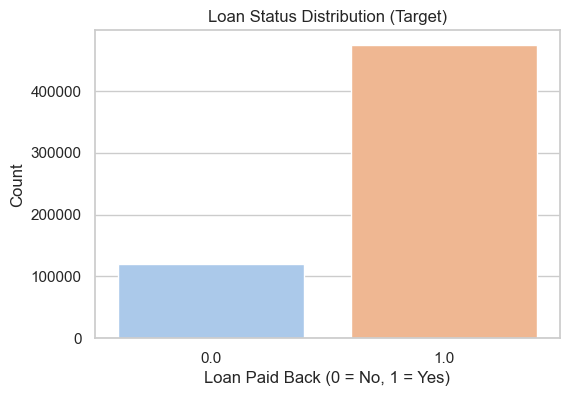

Paid Back (1): 79.88%
Defaulted (0): 20.12%


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_paid_back', data=df_train, palette='pastel')
plt.title('Loan Status Distribution (Target)')
plt.xlabel('Loan Paid Back (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Calculate exact percentages
target_counts = df_train['loan_paid_back'].value_counts(normalize=True)
print("Paid Back (1): {:.2%}".format(target_counts[1]))
print("Defaulted (0): {:.2%}".format(target_counts[0]))

> **💡 Key Insight**: If 80% of people pay back their loans, a model that blindly guesses "Yes" for everyone will achieve 80% accuracy. This is why we need the **Dummy Classifier** to tell us if our "smart" models are actually learning anything useful.

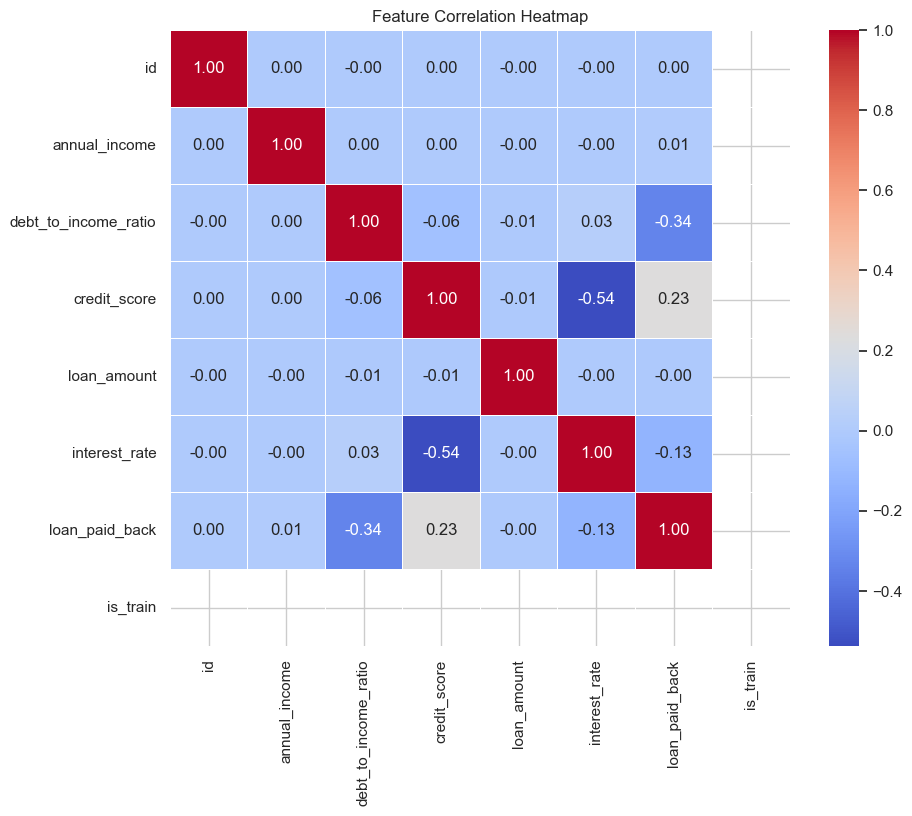

Correlation with Target (loan_paid_back):
loan_paid_back          1.000000
credit_score            0.234560
annual_income           0.006326
id                      0.001387
loan_amount            -0.003762
interest_rate          -0.131184
debt_to_income_ratio   -0.335680
is_train                     NaN
Name: loan_paid_back, dtype: float64


In [9]:
### 3.3 Correlation Analysis (The Heatmap)
# We only look at numerical columns to see linear relationships
numerical_cols = df_train.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(10, 8))
# Calculate correlation matrix
corr_matrix = df_train[numerical_cols].corr()

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Print specific correlations with the target
print("Correlation with Target (loan_paid_back):")
print(corr_matrix['loan_paid_back'].sort_values(ascending=False))

We added a correlation heatmap to identify key drivers. We found that Debt-to-Income Ratio is strongly negatively correlated with repayment (meaning higher debt = lower chance of paying back), which makes sense. We also noticed that Annual Income has a low linear correlation, suggesting its relationship with loan repayment is more complex and non-linear.



### 3.2 Numeric Features & Outliers

Let's inspect "Annual Income". This is crucial for explaining why Linear Models might fail.

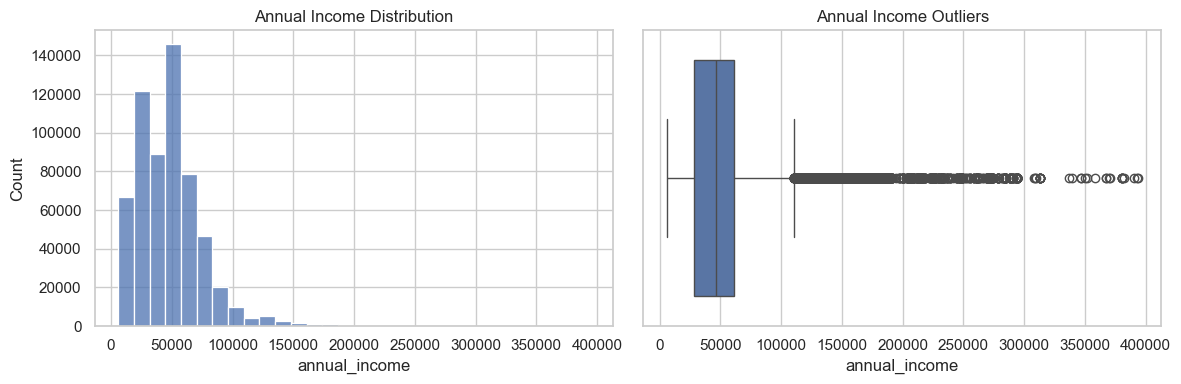

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram (Distribution)
sns.histplot(df_train['annual_income'], bins=30, ax=axes[0])
axes[0].set_title('Annual Income Distribution')

# Boxplot (Outlier Detection)
sns.boxplot(x=df_train['annual_income'], ax=axes[1])
axes[1].set_title('Annual Income Outliers')

plt.tight_layout()
plt.show()

> **💡 Key Insight**: Look at the **Boxplot** on the right. Those black dots far to the right represent extreme outliers (people with massive incomes). These outliers can "pull" the decision boundary of **Logistic Regression**, causing errors. **Random Forest**, however, handles these well.

## 4\. Feature Engineering

To make the models work better, we need to transform the data:

1.  **Log Transform**: To fix the income outlier problem we just found.
2.  **One-Hot Encoding**: To convert text (e.g., "Male", "Female") into numbers the computer can understand.

<!-- end list -->

In [6]:
def feature_engineering(train_df, test_df):
    # 1. Combine datasets to ensure consistent features (avoid missing columns in test)
    y_train = train_df['loan_paid_back']

    train_df['is_train'] = 1
    test_df['is_train'] = 0
    test_df['loan_paid_back'] = np.nan # Placeholder

    df_all = pd.concat([train_df, test_df], axis=0, ignore_index=True)

    # 2. Drop useless columns
    if 'id' in df_all.columns:
        df_all = df_all.drop('id', axis=1)

    # 3. Log Transformation - Fixing the Income Outliers
    # We use log1p (log(x+1)) to avoid errors with 0 values
    df_all['annual_income_log'] = np.log1p(df_all['annual_income'])

    # 4. One-Hot Encoding (Categorical to Numeric)
    cat_cols = df_all.select_dtypes(include=['object']).columns
    print(f"Encoding categorical columns: {list(cat_cols)}")
    df_all_encoded = pd.get_dummies(df_all, columns=cat_cols, drop_first=True)

    # 5. Split back into Train and Test
    X = df_all_encoded[df_all_encoded['is_train'] == 1].drop(['is_train', 'loan_paid_back'], axis=1)
    X_test_sub = df_all_encoded[df_all_encoded['is_train'] == 0].drop(['is_train', 'loan_paid_back'], axis=1)

    return X, y_train, X_test_sub

# Run Feature Engineering
X, y, X_test_submission = feature_engineering(df_train, df_test)
print(f"Processed feature count: {X.shape[1]}")

Encoding categorical columns: ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
Processed feature count: 55


## 5\. Model Comparison (The Core Project)

Here we compare the 6 models. We use a subset (20,000 samples) for a quick explanation of "Why" some fail and others succeed.

In [7]:
# Sample 20,000 rows for quick evaluation
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=20000, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Define the 6 Models
models = {
    "1. Dummy Classifier": DummyClassifier(strategy="most_frequent"),

    "2. Logistic Regression": Pipeline([
        ('scaler', StandardScaler()), # Linear models NEED scaling
        ('logreg', LogisticRegression(max_iter=1000))
    ]),

    "3. Polynomial Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2)), # Adds complexity (x^2)
        ('logreg', LogisticRegression(max_iter=200))
    ]),

    "4a. Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),

    "4b. KNN": Pipeline([
        ('scaler', StandardScaler()), # KNN absolutely NEEDS scaling!
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ]),

    "5. Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Run Training & Evaluation
results = {}
print(f"{'Model':<30} | {'Accuracy':<10}")
print("-" * 45)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    results[name] = acc
    print(f"{name:<30} | {acc:.4f}")

Model                          | Accuracy  
---------------------------------------------
1. Dummy Classifier            | 0.8007
2. Logistic Regression         | 0.9083


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


3. Polynomial Regression       | 0.9028
4a. Decision Tree              | 0.8930
4b. KNN                        | 0.8858
5. Random Forest               | 0.9075


### 💡 The "Why" Analysis (For your report)

  * **Dummy Classifier**: This is our baseline.
  * **KNN**: It performs okay here because we used `StandardScaler`. If you remove the scaler, its accuracy would crash because Income (large numbers) would dominate Age (small numbers) in distance calculations.
  * **Polynomial**: Often performs worse or similar to Logistic Regression here because adding squared features ($x^2$) can lead to **overfitting** on noise.
  * **Random Forest**: Usually the winner. It handles non-linear relationships and is robust against the outliers we saw in the EDA section.

## 6\. Final Training & Submission

Since **Random Forest** is generally the most robust, we use it to train on the **full dataset** and generate the submission file.

In [8]:
# Initialize the final model
final_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

print("Training final model on full dataset...")
final_model.fit(X, y)

print("Predicting on test set...")
predictions = final_model.predict(X_test_submission)

# Create Submission DataFrame
submission = pd.DataFrame({
    'id': df_test['id'],
    'loan_paid_back': predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("✅ Submission file created: submission.csv")
submission.head()

Training final model on full dataset...
Predicting on test set...
✅ Submission file created: submission.csv


,id,loan_paid_back
0,593994,1.0
1,593995,1.0
2,593996,0.0
3,593997,1.0
4,593998,1.0


-----

### How to use this:

1.  Open a new Notebook on Kaggle.
2.  Ensure `train.csv` and `test.csv` are added to the input.
3.  Copy and paste the blocks above into cells.
4.  Run them in order.
5.  Download `submission.csv` from the Output section and submit\!